In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

In [2]:
df = pd.read_csv(r"/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [5]:
# Missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col} Value Counts:")
    print(df[col].value_counts())


Attrition Value Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel Value Counts:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department Value Counts:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField Value Counts:
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender Value Counts:
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole Value Counts:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources     

In [7]:
# Check unique values
for col in df.columns:
    if df[col].nunique() == 1:
        print("Constant column:", col)

# Drop constant columns
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

# Drop EmployeeNumber (ID column)
df.drop(columns=['EmployeeNumber'], inplace=True)


Constant column: EmployeeCount
Constant column: Over18
Constant column: StandardHours


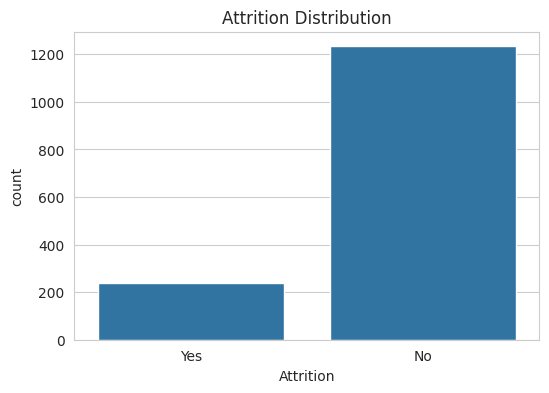

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

print(df['Attrition'].value_counts(normalize=True)*100)


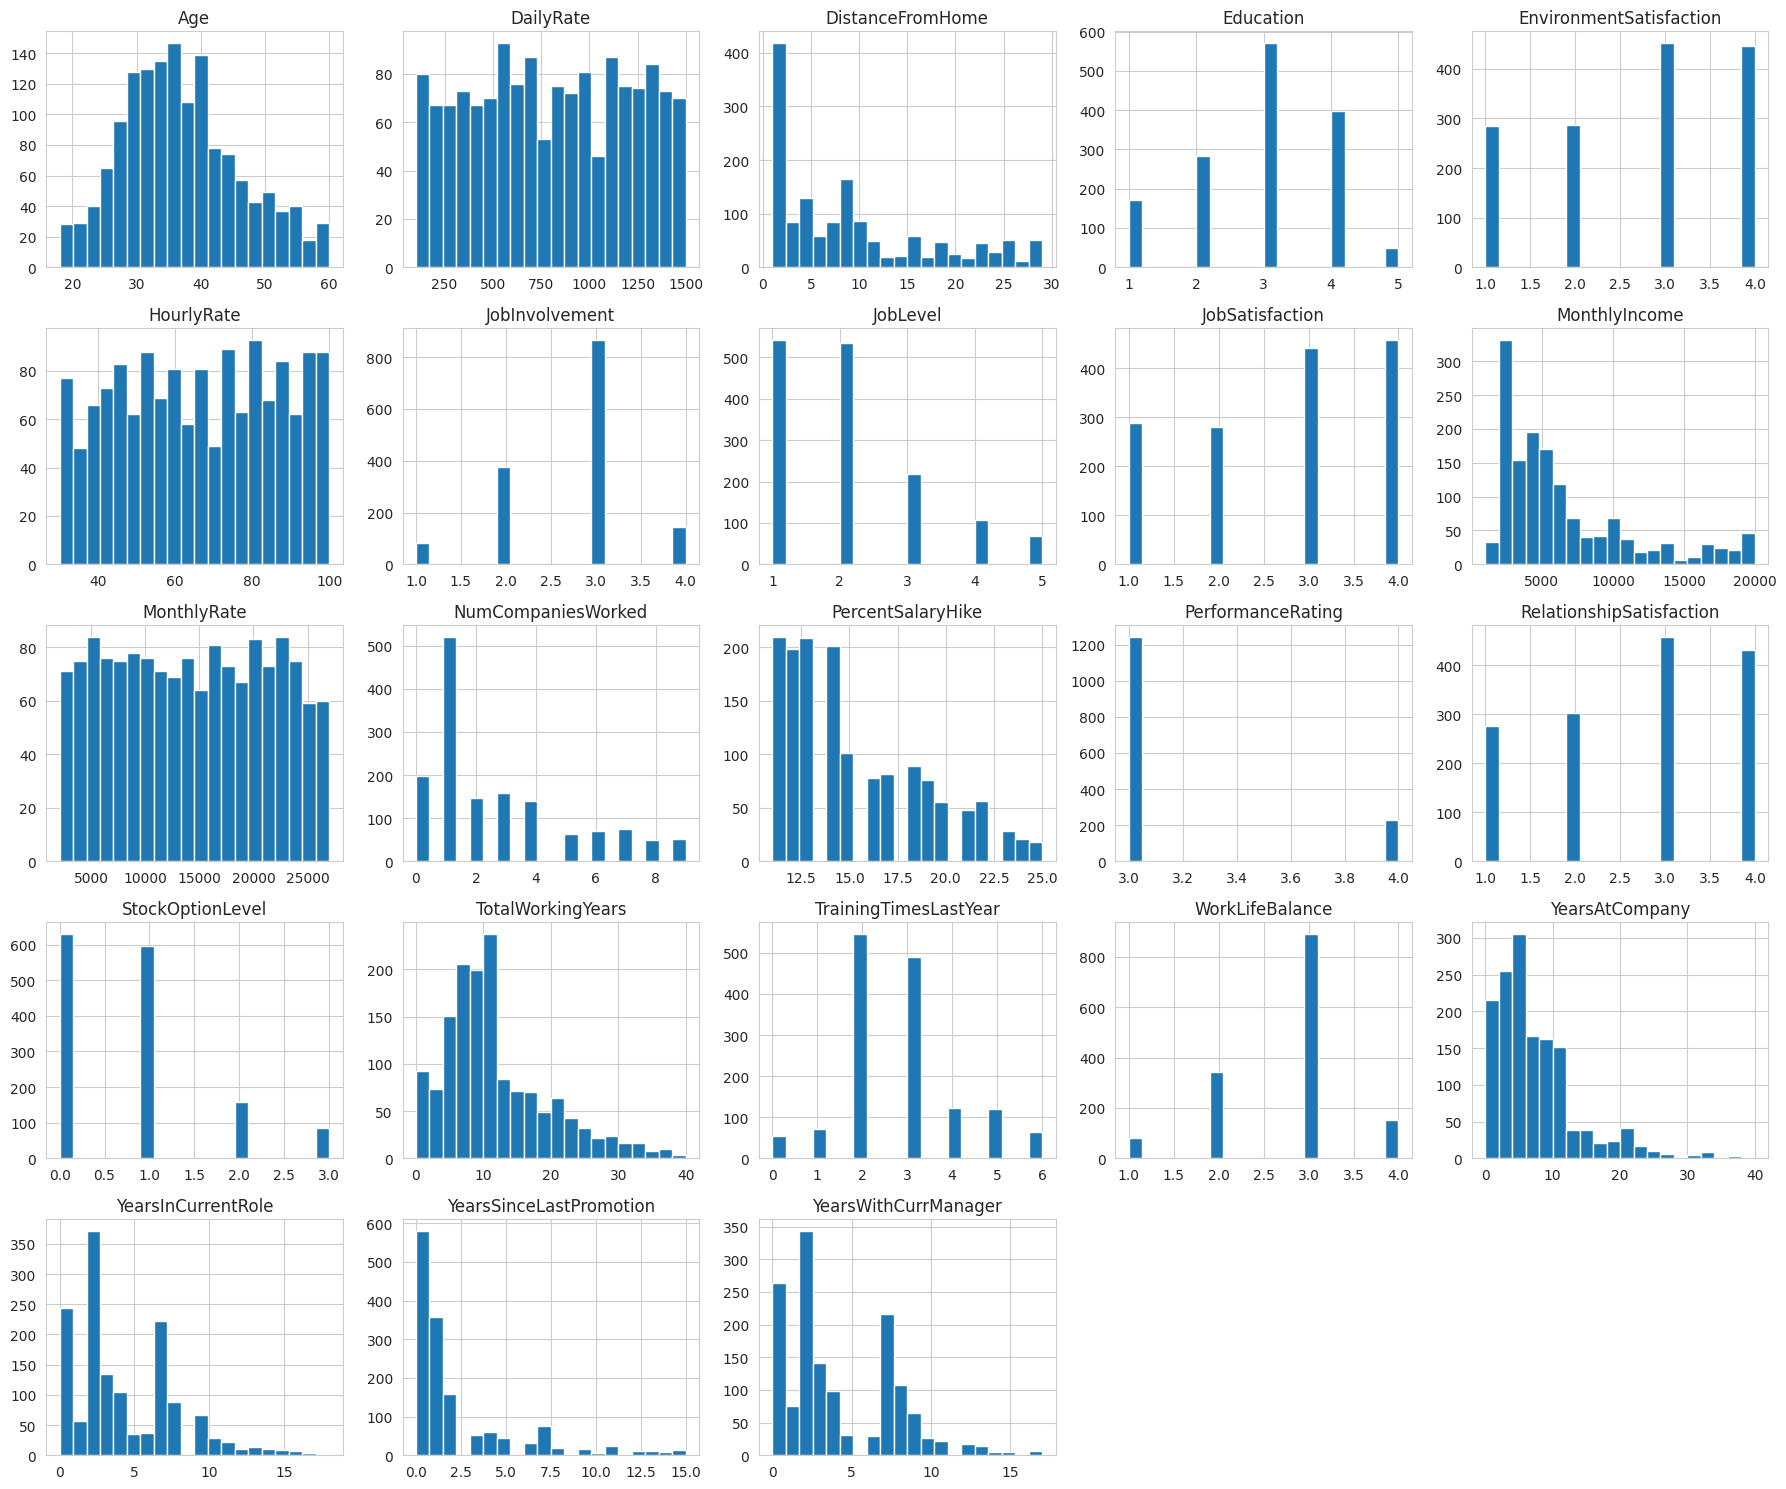

In [9]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(18,15), bins=20)
plt.tight_layout()
plt.show()


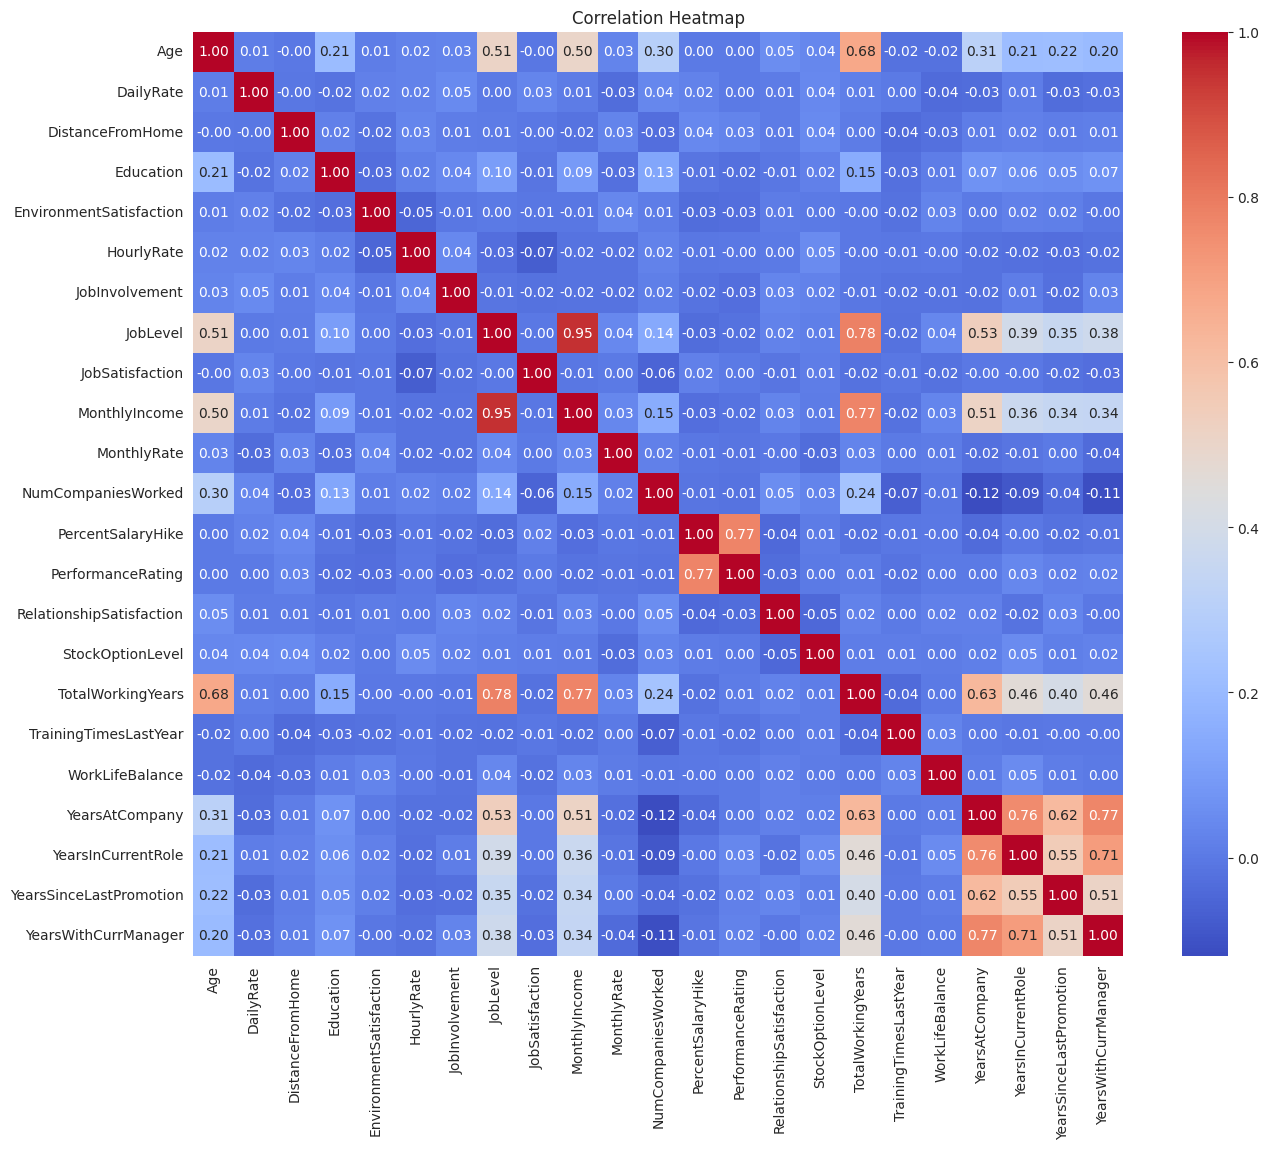

In [10]:
plt.figure(figsize=(15,12))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


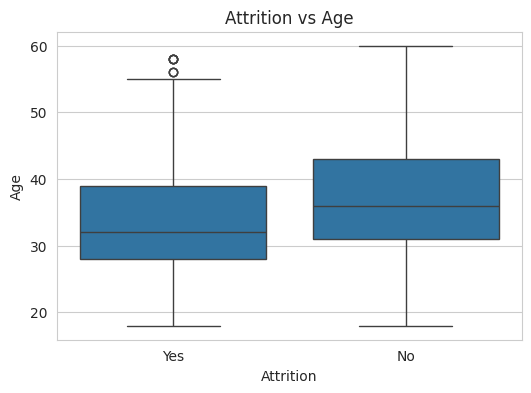

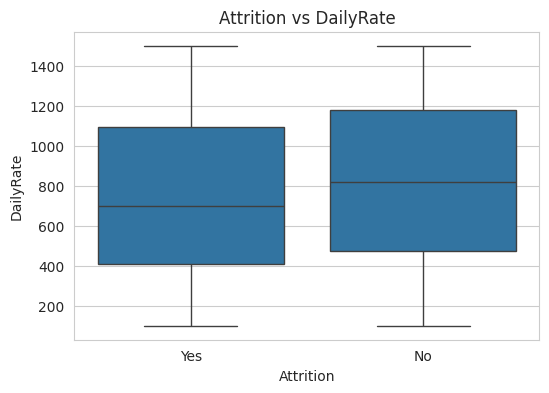

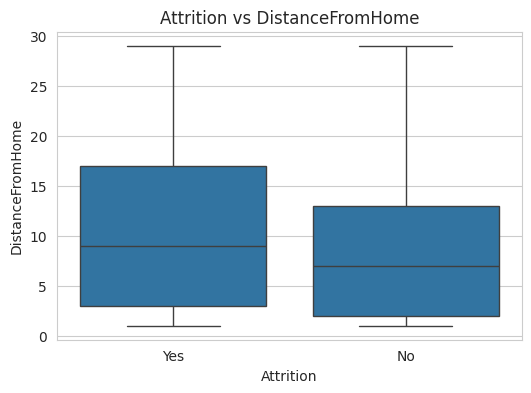

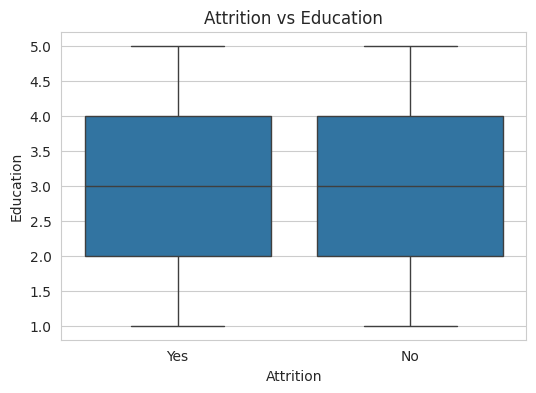

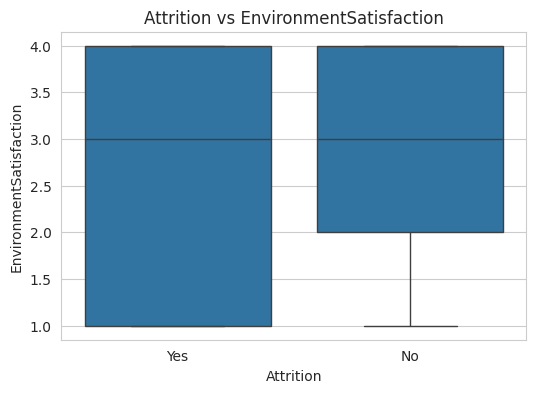

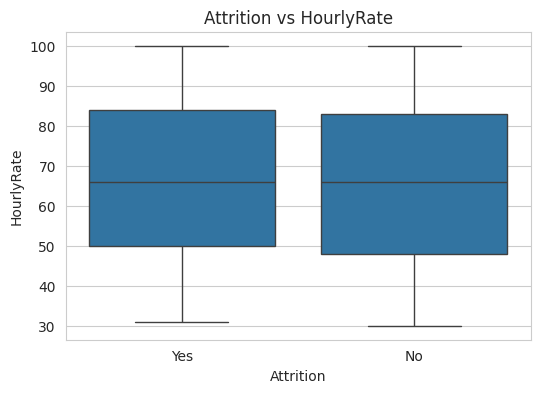

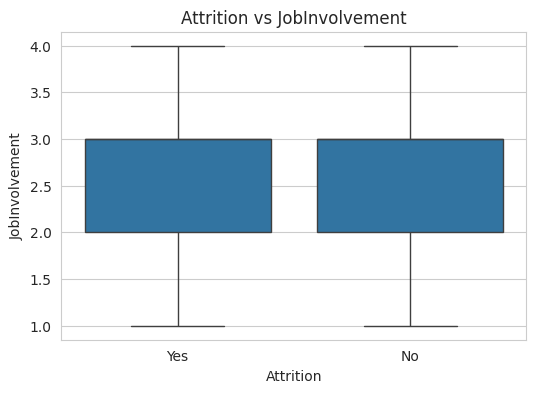

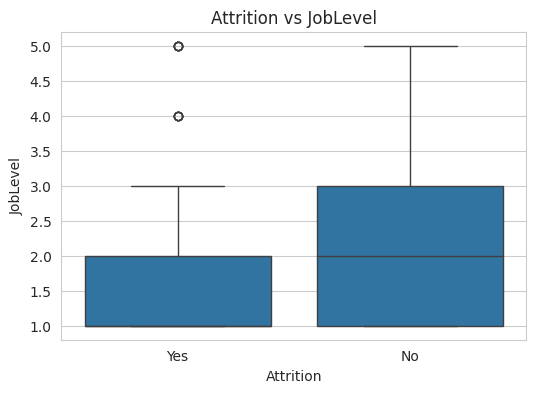

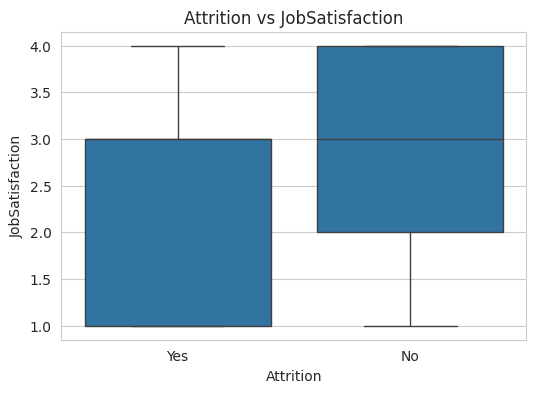

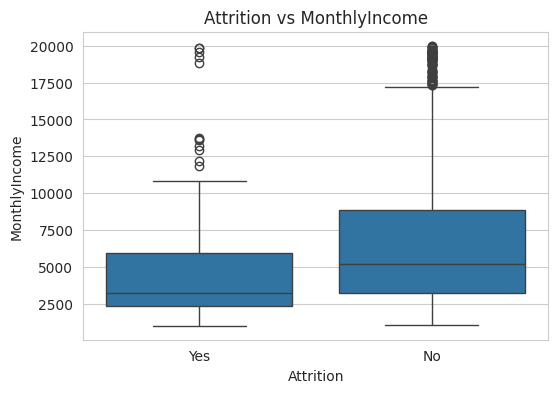

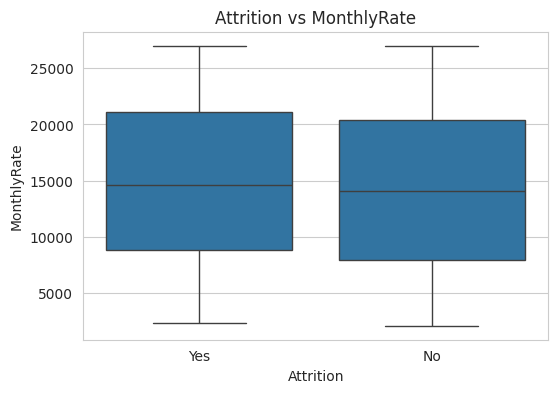

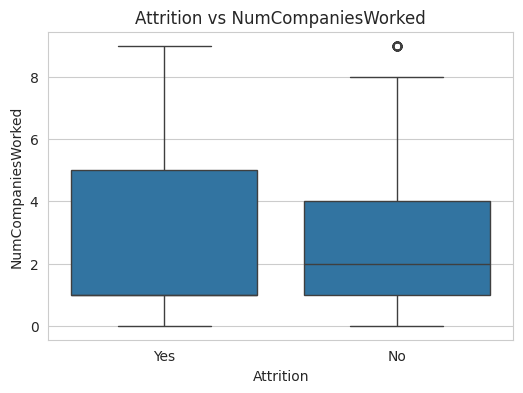

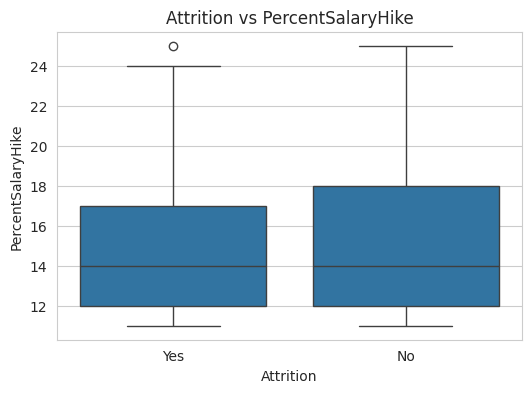

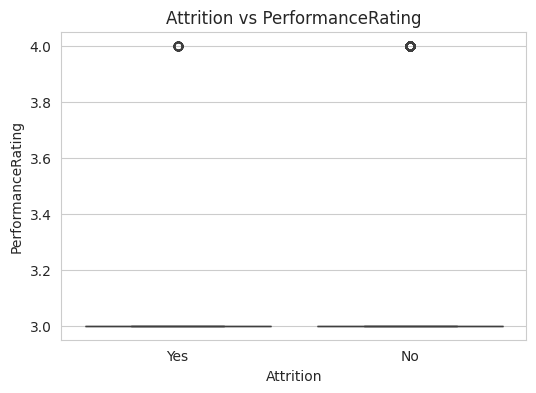

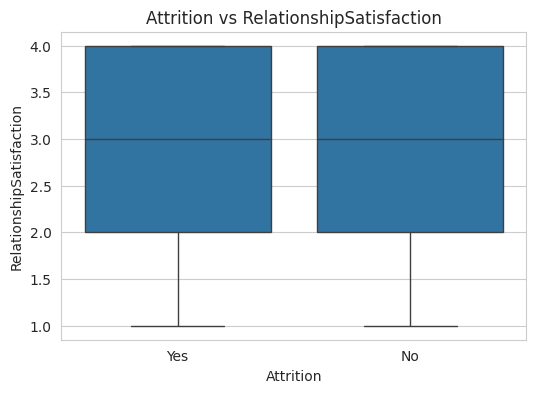

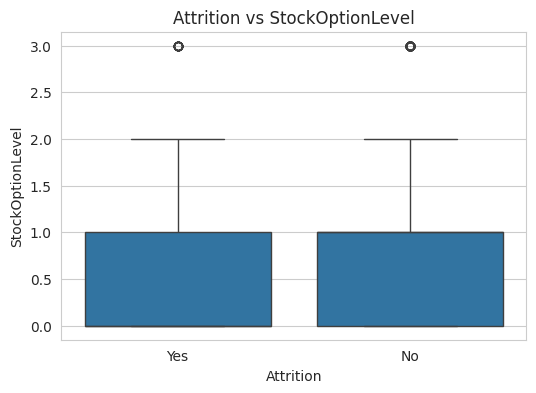

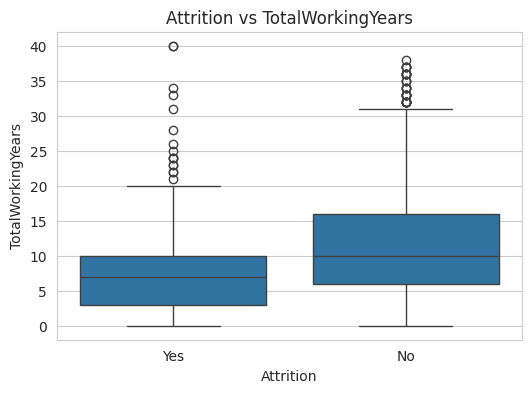

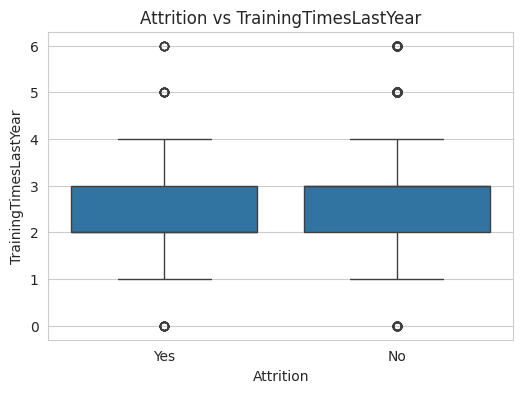

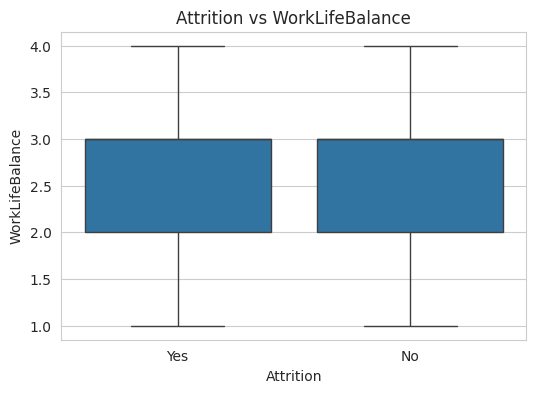

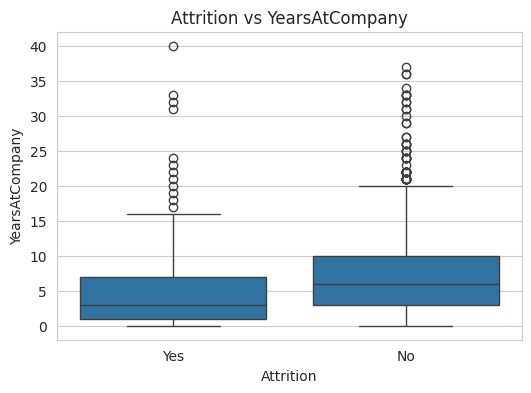

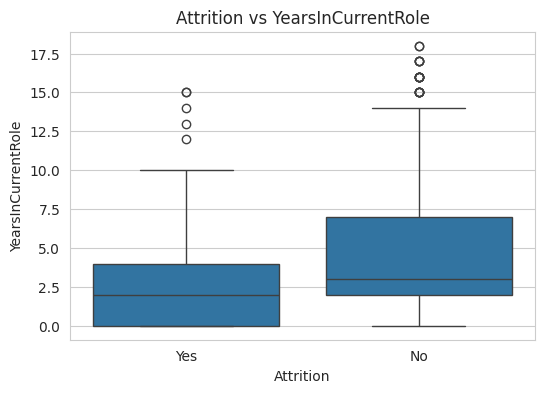

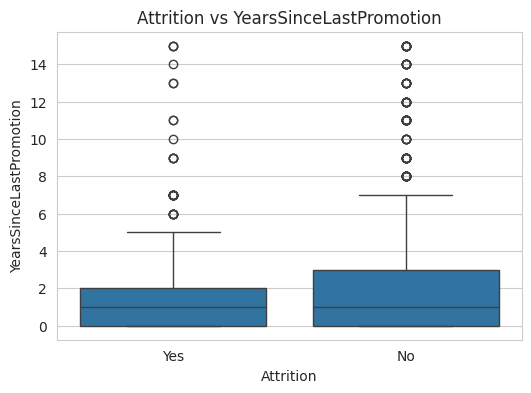

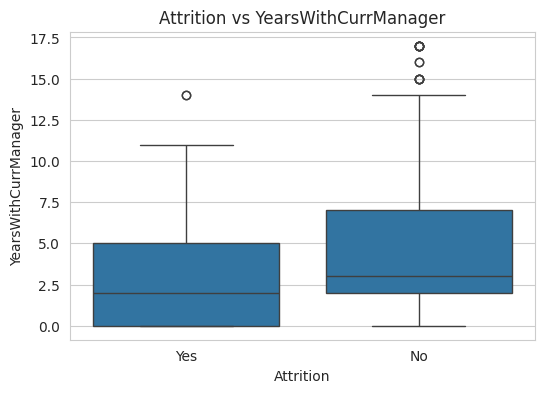

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f"Attrition vs {col}")
    plt.show()


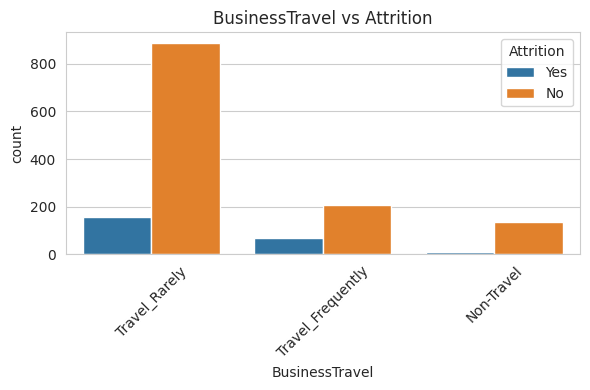

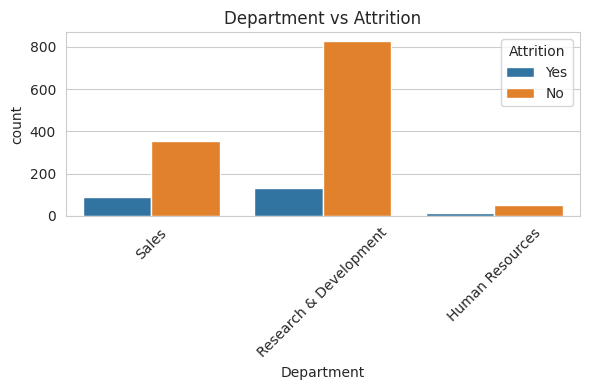

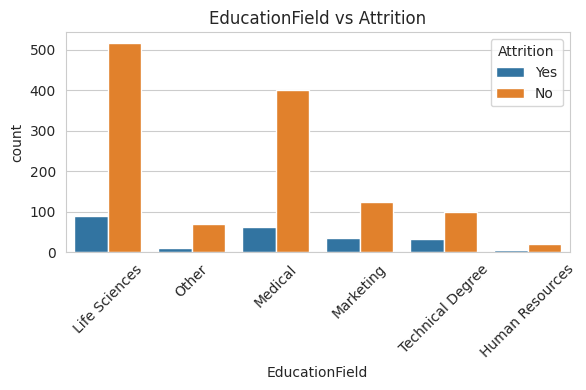

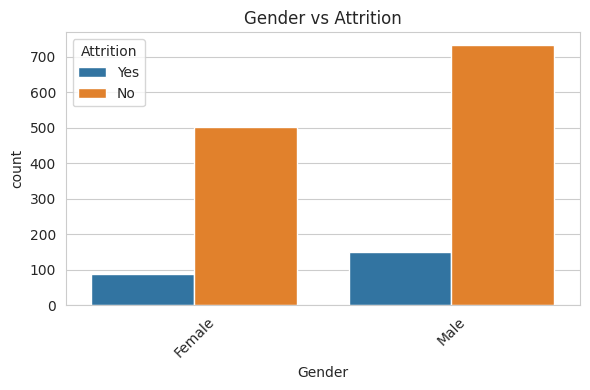

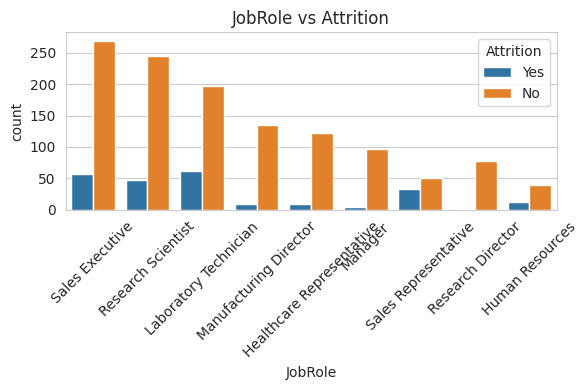

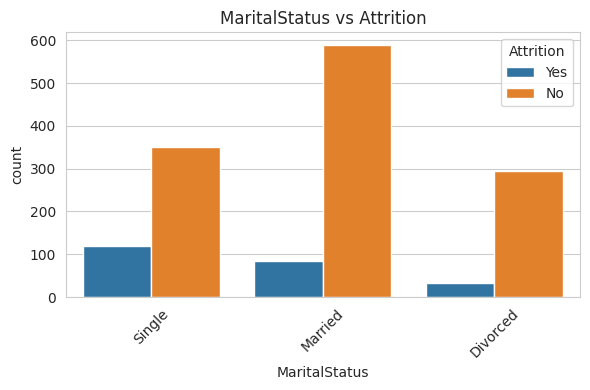

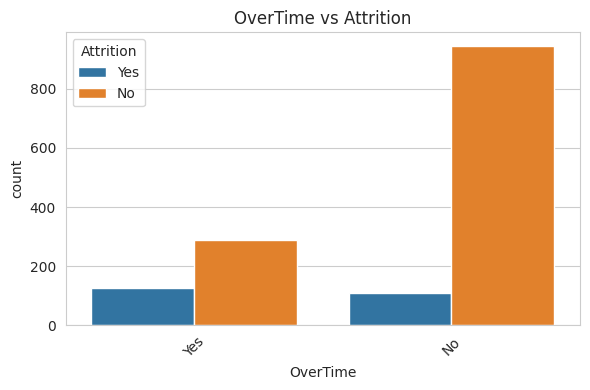

In [12]:
# Recreate categorical column list AFTER dropping columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Plot safely
for col in cat_cols:
    if col != 'Attrition' and col in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue='Attrition', data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Attrition")
        plt.tight_layout()
        plt.show()

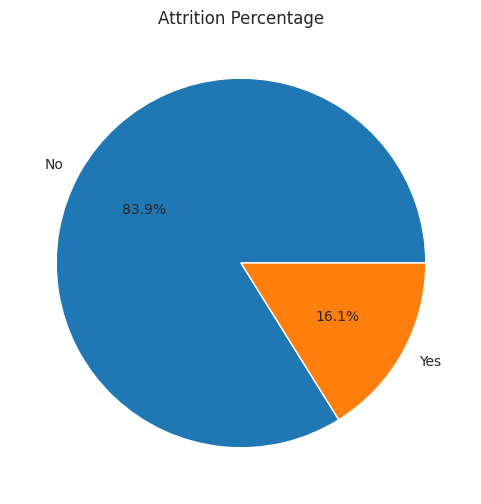

In [13]:
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title("Attrition Percentage")
plt.ylabel("")
plt.show()


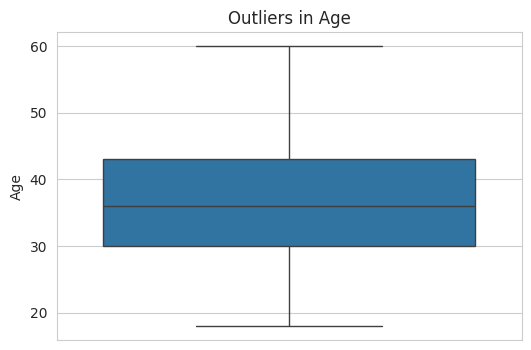

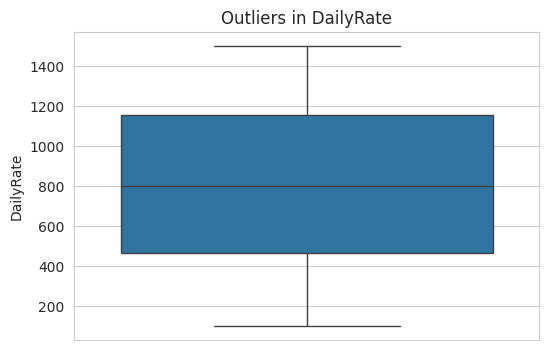

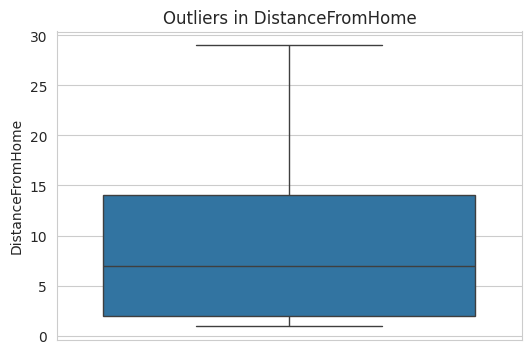

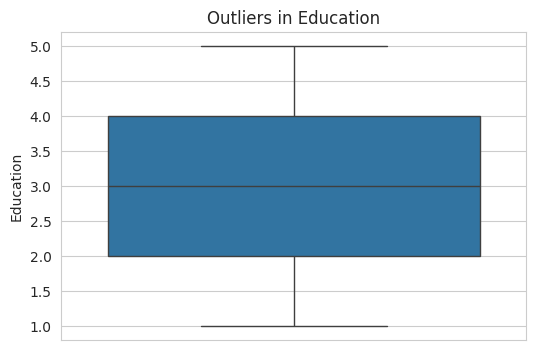

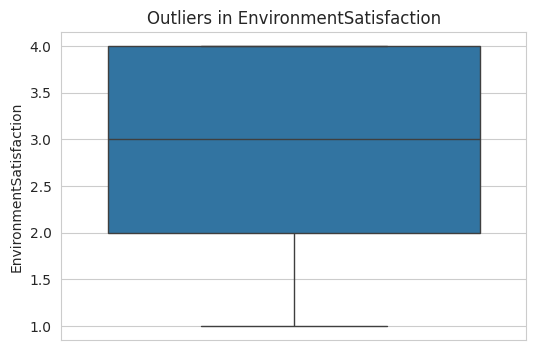

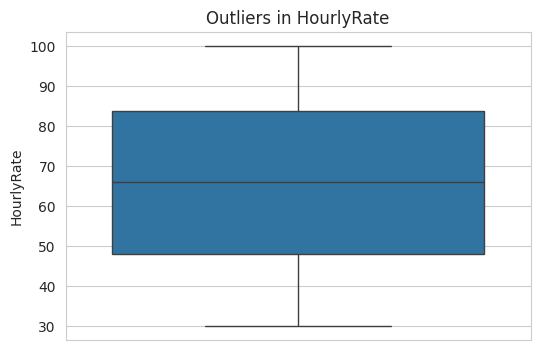

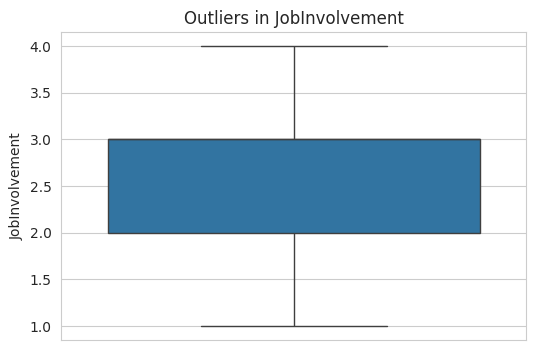

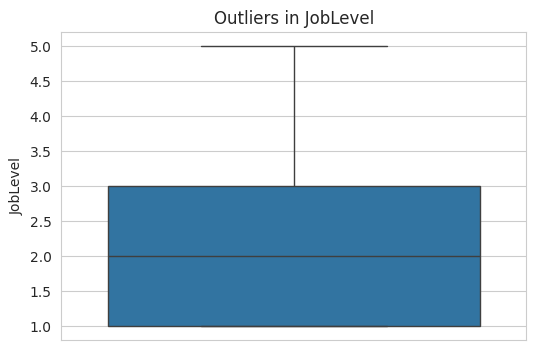

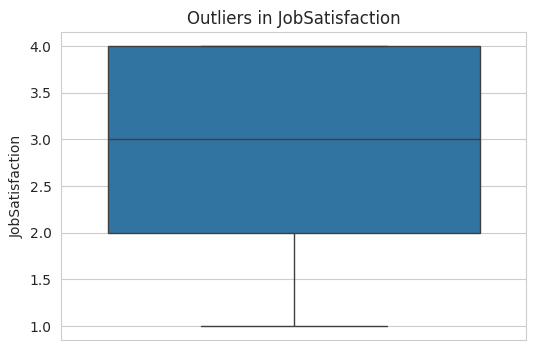

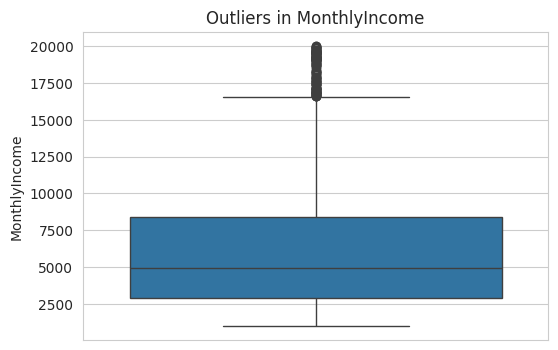

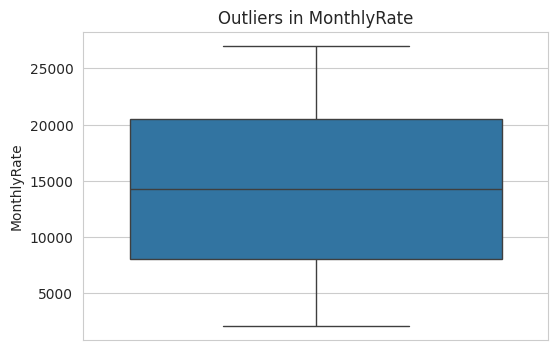

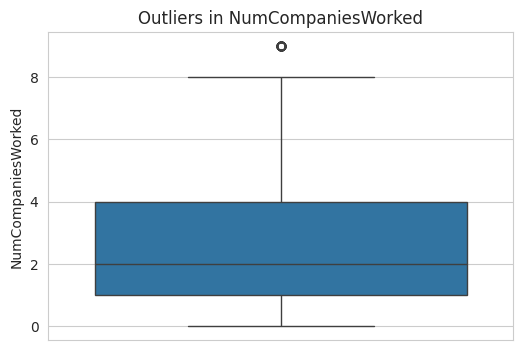

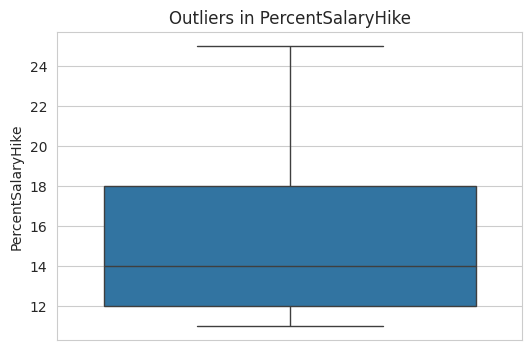

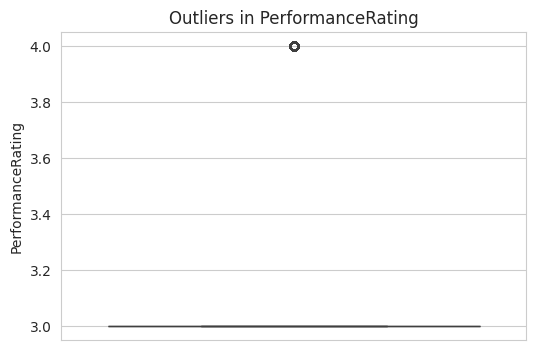

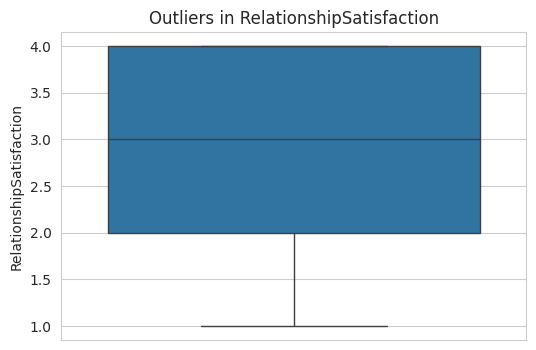

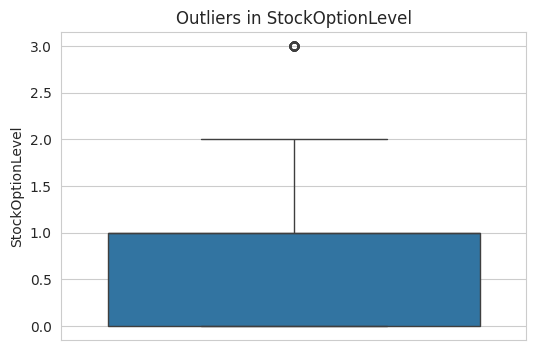

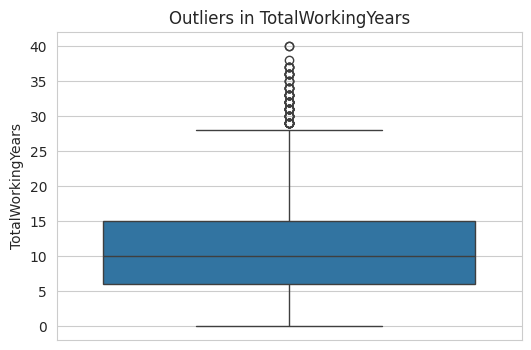

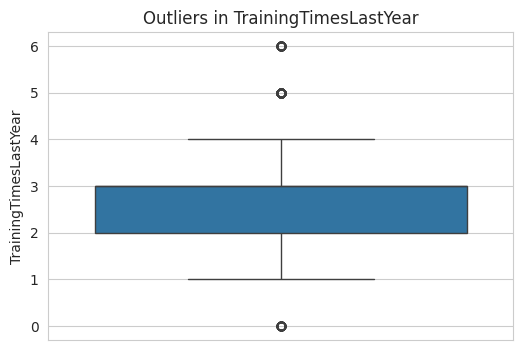

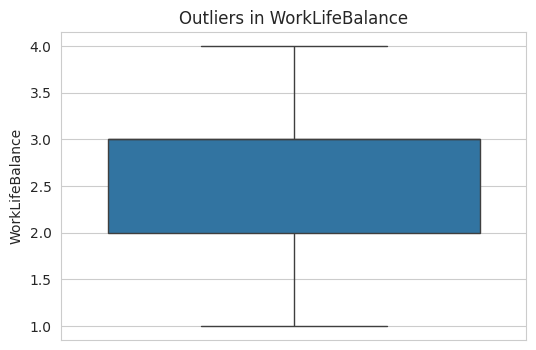

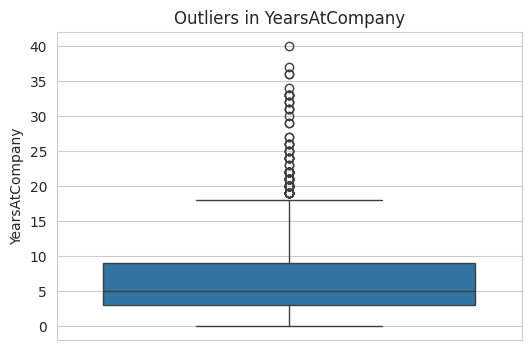

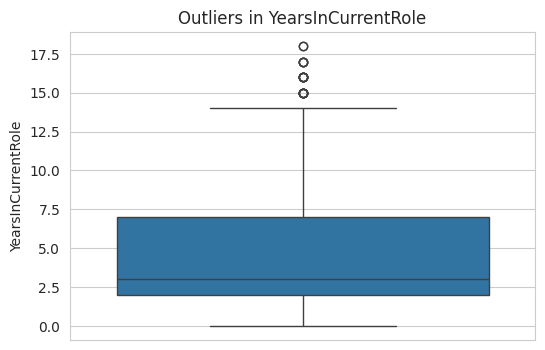

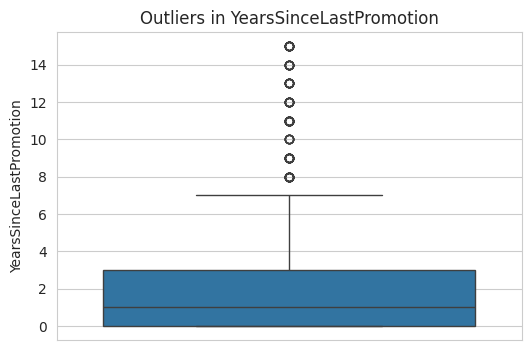

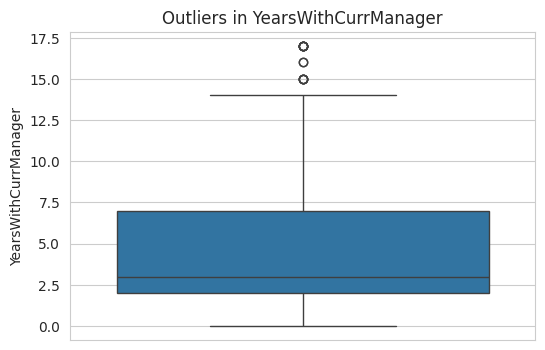

In [14]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

### To critically assess the current employee retention models, fuzzy inference systems, and heuristic optimisation techniques in the literature of decision support.

In [16]:
# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [17]:
# Encode categorical variables
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
# Split features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']


In [19]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [20]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.8741496598639455
ROC-AUC: 0.675295029718322
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest
Accuracy: 0.8367346938775511
ROC-AUC: 0.5496597467482126
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.46      0.13      0.20        47

    accuracy                           0.84       294
   macro avg       0.66      0.55      0.55       294
weighted avg       0.79      0.84      0.80       294



In [23]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define fuzzy variables
job_sat = ctrl.Antecedent(np.arange(1, 5, 1), 'job_sat')
income = ctrl.Antecedent(np.arange(0, 20000, 1000), 'income')
worklife = ctrl.Antecedent(np.arange(1, 5, 1), 'worklife')
attrition_risk = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'attrition_risk')

# Membership functions
job_sat.automf(3)
worklife.automf(3)

income['low'] = fuzz.trimf(income.universe, [0, 0, 8000])
income['medium'] = fuzz.trimf(income.universe, [5000, 10000, 15000])
income['high'] = fuzz.trimf(income.universe, [12000, 20000, 20000])

attrition_risk['low'] = fuzz.trimf(attrition_risk.universe, [0,0,0.5])
attrition_risk['high'] = fuzz.trimf(attrition_risk.universe, [0.4,1,1])

# Fuzzy Rules
rule1 = ctrl.Rule(job_sat['poor'] & worklife['poor'], attrition_risk['high'])
rule2 = ctrl.Rule(income['low'] & job_sat['poor'], attrition_risk['high'])
rule3 = ctrl.Rule(job_sat['good'] & worklife['good'], attrition_risk['low'])

system = ctrl.ControlSystem([rule1, rule2, rule3])
sim = ctrl.ControlSystemSimulation(system)

# Test on one employee
sim.input['job_sat'] = 2
sim.input['income'] = 4000
sim.input['worklife'] = 2
sim.compute()

print("Fuzzy Attrition Risk:", sim.output['attrition_risk'])


Fuzzy Attrition Risk: 0.7466666666666667


In [24]:
#### from deap import base, creator, tools, algorithms
import random
from sklearn.model_selection import cross_val_score
from deap import base, creator, tools, algorithms

# Fitness function
def evalFeatureSelection(individual):
    selected = [i for i in range(len(individual)) if individual[i] == 1]

    if len(selected) == 0:
        return 0,

    X_subset = X.iloc[:, selected]

    model = RandomForestClassifier(n_estimators=100)
    score = cross_val_score(model, X_subset, y, cv=3).mean()

    return score,

# GA setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_bool, n=X.shape[1])
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evalFeatureSelection)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=20)

algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2,
                    ngen=10, verbose=False)

best_ind = tools.selBest(pop, 1)[0]

print("Best Feature Subset:", best_ind)


Best Feature Subset: [1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1]


In [25]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
}

print("\nModel Comparison:")
for k,v in results.items():
    print(k, ":", round(v,4))



Model Comparison:
Logistic Regression : 0.8741
Random Forest : 0.8367


### To model an employee retention risk fuzzy inference system that uses behavioural, organisational, and performance-related predictors when faced with uncertainty.

In [26]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [27]:
# 1️⃣ Behavioural Variables

job_sat = ctrl.Antecedent(np.arange(1, 5, 1), 'job_sat')
work_life = ctrl.Antecedent(np.arange(1, 5, 1), 'work_life')
job_inv = ctrl.Antecedent(np.arange(1, 5, 1), 'job_inv')
overtime = ctrl.Antecedent(np.arange(0, 2, 1), 'overtime')  # 0=No, 1=Yes

In [28]:
# 2️⃣ Organisational Variables

env_sat = ctrl.Antecedent(np.arange(1, 5, 1), 'env_sat')
income = ctrl.Antecedent(np.arange(1000, 20001, 1000), 'income')
years_company = ctrl.Antecedent(np.arange(0, 41, 1), 'years_company')

In [29]:
# 3️⃣ Performance Variables

performance = ctrl.Antecedent(np.arange(1, 5, 1), 'performance')
salary_hike = ctrl.Antecedent(np.arange(0, 26, 1), 'salary_hike')

In [30]:
# 4️⃣ Output Variable

retention_risk = ctrl.Consequent(np.arange(0, 101, 1), 'retention_risk')

In [31]:
job_sat.automf(3)        # poor, average, good
work_life.automf(3)
job_inv.automf(3)
env_sat.automf(3)
performance.automf(3)

overtime['no'] = fuzz.trimf(overtime.universe, [0, 0, 1])
overtime['yes'] = fuzz.trimf(overtime.universe, [0, 1, 1])


In [32]:
income['low'] = fuzz.trimf(income.universe, [1000, 1000, 8000])
income['medium'] = fuzz.trimf(income.universe, [5000, 10000, 15000])
income['high'] = fuzz.trimf(income.universe, [12000, 20000, 20000])

years_company['new'] = fuzz.trimf(years_company.universe, [0, 0, 5])
years_company['mid'] = fuzz.trimf(years_company.universe, [3, 10, 20])
years_company['senior'] = fuzz.trimf(years_company.universe, [15, 40, 40])


In [33]:
salary_hike['low'] = fuzz.trimf(salary_hike.universe, [0, 0, 10])
salary_hike['medium'] = fuzz.trimf(salary_hike.universe, [5, 12, 20])
salary_hike['high'] = fuzz.trimf(salary_hike.universe, [15, 25, 25])

In [34]:
retention_risk['low'] = fuzz.trimf(retention_risk.universe, [0, 0, 40])
retention_risk['medium'] = fuzz.trimf(retention_risk.universe, [30, 50, 70])
retention_risk['high'] = fuzz.trimf(retention_risk.universe, [60, 100, 100])

In [35]:
rule1 = ctrl.Rule(job_sat['poor'] & work_life['poor'], retention_risk['high'])

rule2 = ctrl.Rule(overtime['yes'] & job_sat['poor'],
                  retention_risk['high'])

rule3 = ctrl.Rule(income['low'] & salary_hike['low'],
                  retention_risk['high'])

rule4 = ctrl.Rule(env_sat['good'] & performance['good'],
                  retention_risk['low'])

rule5 = ctrl.Rule(job_sat['good'] & work_life['good'] & income['high'],
                  retention_risk['low'])

rule6 = ctrl.Rule(years_company['new'] & job_inv['poor'],
                  retention_risk['high'])

rule7 = ctrl.Rule(performance['average'] & salary_hike['medium'],
                  retention_risk['medium'])

In [36]:
retention_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4,
    rule5, rule6, rule7
])

retention_sim = ctrl.ControlSystemSimulation(retention_ctrl)


In [37]:
retention_sim.input['job_sat'] = 2
retention_sim.input['work_life'] = 2
retention_sim.input['job_inv'] = 2
retention_sim.input['overtime'] = 1
retention_sim.input['env_sat'] = 2
retention_sim.input['income'] = 4000
retention_sim.input['years_company'] = 3
retention_sim.input['performance'] = 2
retention_sim.input['salary_hike'] = 8

retention_sim.compute()

print("Retention Risk Score (0-100):",
      retention_sim.output['retention_risk'])

Retention Risk Score (0-100): 64.94711757339344


In [38]:
risk_score = retention_sim.output['retention_risk']

if risk_score < 40:
    print("Low Attrition Risk")
elif risk_score < 70:
    print("Moderate Attrition Risk")
else:
    print("High Attrition Risk")


Moderate Attrition Risk


### Input from User

In [39]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define Fuzzy Variables

job_sat = ctrl.Antecedent(np.arange(1, 5, 1), 'job_sat')
work_life = ctrl.Antecedent(np.arange(1, 5, 1), 'work_life')
job_inv = ctrl.Antecedent(np.arange(1, 5, 1), 'job_inv')
overtime = ctrl.Antecedent(np.arange(0, 2, 1), 'overtime')

env_sat = ctrl.Antecedent(np.arange(1, 5, 1), 'env_sat')
income = ctrl.Antecedent(np.arange(1000, 20001, 1000), 'income')
years_company = ctrl.Antecedent(np.arange(0, 41, 1), 'years_company')

performance = ctrl.Antecedent(np.arange(1, 5, 1), 'performance')
salary_hike = ctrl.Antecedent(np.arange(0, 26, 1), 'salary_hike')

retention_risk = ctrl.Consequent(np.arange(0, 101, 1), 'retention_risk')

# Membership Functions

job_sat.automf(3)
work_life.automf(3)
job_inv.automf(3)
env_sat.automf(3)
performance.automf(3)

overtime['no'] = fuzz.trimf(overtime.universe, [0, 0, 1])
overtime['yes'] = fuzz.trimf(overtime.universe, [0, 1, 1])

income['low'] = fuzz.trimf(income.universe, [1000, 1000, 8000])
income['medium'] = fuzz.trimf(income.universe, [5000, 10000, 15000])
income['high'] = fuzz.trimf(income.universe, [12000, 20000, 20000])

years_company['new'] = fuzz.trimf(years_company.universe, [0, 0, 5])
years_company['mid'] = fuzz.trimf(years_company.universe, [3, 10, 20])
years_company['senior'] = fuzz.trimf(years_company.universe, [15, 40, 40])

salary_hike['low'] = fuzz.trimf(salary_hike.universe, [0, 0, 10])
salary_hike['medium'] = fuzz.trimf(salary_hike.universe, [5, 12, 20])
salary_hike['high'] = fuzz.trimf(salary_hike.universe, [15, 25, 25])

retention_risk['low'] = fuzz.trimf(retention_risk.universe, [0, 0, 40])
retention_risk['medium'] = fuzz.trimf(retention_risk.universe, [30, 50, 70])
retention_risk['high'] = fuzz.trimf(retention_risk.universe, [60, 100, 100])


# Fuzzy Rules

rule1 = ctrl.Rule(job_sat['poor'] & work_life['poor'], retention_risk['high'])
rule2 = ctrl.Rule(overtime['yes'] & job_sat['poor'], retention_risk['high'])
rule3 = ctrl.Rule(income['low'] & salary_hike['low'], retention_risk['high'])
rule4 = ctrl.Rule(env_sat['good'] & performance['good'], retention_risk['low'])
rule5 = ctrl.Rule(job_sat['good'] & work_life['good'] & income['high'], retention_risk['low'])
rule6 = ctrl.Rule(years_company['new'] & job_inv['poor'], retention_risk['high'])
rule7 = ctrl.Rule(performance['average'] & salary_hike['medium'], retention_risk['medium'])

retention_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7
])

retention_sim = ctrl.ControlSystemSimulation(retention_ctrl)

# Take Input From User

print("\nEnter Employee Details (Use scale 1-4 where applicable)\n")

retention_sim.input['job_sat'] = int(input("Job Satisfaction (1=Low, 4=High): "))
retention_sim.input['work_life'] = int(input("Work Life Balance (1=Low, 4=High): "))
retention_sim.input['job_inv'] = int(input("Job Involvement (1=Low, 4=High): "))
retention_sim.input['overtime'] = int(input("Overtime (0=No, 1=Yes): "))
retention_sim.input['env_sat'] = int(input("Environment Satisfaction (1-4): "))
retention_sim.input['income'] = float(input("Monthly Income (1000-20000): "))
retention_sim.input['years_company'] = int(input("Years At Company (0-40): "))
retention_sim.input['performance'] = int(input("Performance Rating (1-4): "))
retention_sim.input['salary_hike'] = float(input("Percent Salary Hike (0-25): "))


# Compute Risk

retention_sim.compute()

risk_score = retention_sim.output['retention_risk']

print("\nPredicted Retention Risk Score:", round(risk_score,2))

# Interpret Result

if risk_score < 40:
    print("Risk Level: LOW Attrition Risk")
elif risk_score < 70:
    print("Risk Level: MODERATE Attrition Risk")
else:
    print("Risk Level: HIGH Attrition Risk")



Enter Employee Details (Use scale 1-4 where applicable)

Job Satisfaction (1=Low, 4=High): 4
Work Life Balance (1=Low, 4=High): 5
Job Involvement (1=Low, 4=High): 4
Overtime (0=No, 1=Yes): 2
Environment Satisfaction (1-4): 3
Monthly Income (1000-20000): 5000
Years At Company (0-40): 12
Performance Rating (1-4): 3
Percent Salary Hike (0-25): 20

Predicted Retention Risk Score: 16.89
Risk Level: LOW Attrition Risk


### To create a heuristic optimisation mechanism (greedy-based approach) to prioritise retention interventions based on an organisational constraint like limited budget and resources.

<h3>Mathematical Representation of Greedy-Based Retention Optimisation</h3>

<p><b>Objective Function:</b></p>

<p>
\[
\max \sum_{i \in S} Risk_i
\]
</p>

<p><b>Subject to Budget Constraint:</b></p>

<p>
\[
\sum_{i \in S} Cost_i \leq Budget
\]
</p>

<p><b>Greedy Approximation Strategy:</b></p>

<p>
Select employees in descending order of:
</p>

<p>
\[
\frac{Risk_i}{Cost_i}
\]
</p>

<p>
Where:
</p>

<ul>
<li><b>Risk<sub>i</sub></b> = Predicted retention risk of employee <i>i</i></li>
<li><b>Cost<sub>i</sub></b> = Intervention cost for employee <i>i</i></li>
<li><b>S</b> = Selected set of employees</li>
<li><b>Budget</b> = Organisational financial constraint</li>
</ul>


In [40]:
df_model = df.copy()

# ----- SAFE TARGET ENCODING -----
if df_model['Attrition'].dtype == 'object':
    df_model['Attrition'] = df_model['Attrition'].map({'Yes':1, 'No':0})

# Remove any accidental NaN rows
df_model = df_model.dropna(subset=['Attrition'])

# Separate features and target
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

# Check for any remaining NaN in X
print("Missing in X:", X.isnull().sum().sum())
print("Missing in y:", y.isnull().sum())


Missing in X: 0
Missing in y: 0


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [42]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Generate retention risk for entire dataset
df_model['retention_risk'] = rf.predict_proba(X)[:, 1]

print("Retention risk column created successfully ")

Accuracy: 0.8367346938775511
ROC-AUC: 0.7891721939874236
Retention risk column created successfully 


In [43]:
df_model[['retention_risk']].head()

,retention_risk
0,0.705
1,0.025
2,0.460
3,0.280
4,0.115


In [44]:
def calculate_intervention_cost(row):
    base_cost = 5000

    # Higher salary employees cost more to retain
    salary_factor = row['MonthlyIncome'] * 0.2

    return base_cost + salary_factor

df_model['intervention_cost'] = df_model.apply(calculate_intervention_cost, axis=1)

In [45]:
def greedy_retention_selection(data, total_budget):

    # Calculate priority score (impact per cost)
    data['priority_score'] = data['retention_risk'] / data['intervention_cost']

    # Sort by highest priority
    data_sorted = data.sort_values(by='priority_score', ascending=False)

    selected_employees = []
    used_budget = 0

    for index, row in data_sorted.iterrows():
        cost = row['intervention_cost']

        if used_budget + cost <= total_budget:
            selected_employees.append(index)
            used_budget += cost
        else:
            break

    return selected_employees, used_budget


In [46]:
TOTAL_BUDGET = 200000  # Example organisational constraint

selected_ids, spent = greedy_retention_selection(df_model, TOTAL_BUDGET)

print("Total Employees Selected:", len(selected_ids))
print("Total Budget Used:", round(spent,2))
print("Remaining Budget:", round(TOTAL_BUDGET - spent,2))


Total Employees Selected: 36
Total Budget Used: 194695.0
Remaining Budget: 5305.0


In [47]:
priority_list = df_model.loc[selected_ids]

priority_list = priority_list.sort_values(by='priority_score', ascending=False)

priority_list[['retention_risk','intervention_cost','priority_score']].head()


,retention_risk,intervention_cost,priority_score
127,0.945,5335.0,0.000177
1012,0.910,5271.8,0.000173
1016,0.900,5252.2,0.000171
777,0.905,5283.2,0.000171
463,0.930,5468.0,0.000170


###	To combine the fuzzy inference and optimisation elements into an overall prescriptive decision-support system of employee retention management.

### Build Fuzzy Risk Engine

In [48]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from pulp import *
from sklearn.preprocessing import MinMaxScaler

In [49]:
features = ['JobSatisfaction', 'WorkLifeBalance',
            'EnvironmentSatisfaction', 'MonthlyIncome',
            'OverTime', 'YearsAtCompany']

data = df[features + ['Attrition']].copy()

In [50]:
scaler = MinMaxScaler()
data[['MonthlyIncome','YearsAtCompany']] = scaler.fit_transform(
    data[['MonthlyIncome','YearsAtCompany']]
)

In [51]:
# Antecedents (Inputs)
job_sat = ctrl.Antecedent(np.arange(0, 5, 1), 'job_sat')
wlb = ctrl.Antecedent(np.arange(0, 5, 1), 'wlb')
env_sat = ctrl.Antecedent(np.arange(0, 5, 1), 'env_sat')
income = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'income')
overtime = ctrl.Antecedent(np.arange(0, 2, 1), 'overtime')
years = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'years')

# Consequent (Output)
risk = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'risk')

In [52]:
# Satisfaction & WLB
for var in [job_sat, wlb, env_sat]:
    var['low'] = fuzz.trimf(var.universe, [0, 0, 2])
    var['medium'] = fuzz.trimf(var.universe, [1, 2.5, 4])
    var['high'] = fuzz.trimf(var.universe, [3, 4, 4])

# Income
income['low'] = fuzz.trimf(income.universe, [0, 0, 0.4])
income['medium'] = fuzz.trimf(income.universe, [0.3, 0.5, 0.7])
income['high'] = fuzz.trimf(income.universe, [0.6, 1, 1])

# Overtime
overtime['no'] = fuzz.trimf(overtime.universe, [0, 0, 1])
overtime['yes'] = fuzz.trimf(overtime.universe, [0, 1, 1])

# Years at company
years['low'] = fuzz.trimf(years.universe, [0, 0, 0.3])
years['medium'] = fuzz.trimf(years.universe, [0.2, 0.5, 0.8])
years['high'] = fuzz.trimf(years.universe, [0.7, 1, 1])

# Output Risk
risk['low'] = fuzz.trimf(risk.universe, [0, 0, 0.4])
risk['medium'] = fuzz.trimf(risk.universe, [0.3, 0.5, 0.7])
risk['high'] = fuzz.trimf(risk.universe, [0.6, 1, 1])

In [53]:
rules = [
    ctrl.Rule(job_sat['low'] & wlb['low'], risk['high']),
    ctrl.Rule(overtime['yes'] & wlb['low'], risk['high']),
    ctrl.Rule(env_sat['low'] & income['low'], risk['high']),
    ctrl.Rule(job_sat['medium'] & wlb['medium'], risk['medium']),
    ctrl.Rule(job_sat['high'] & wlb['high'], risk['low']),
    ctrl.Rule(income['high'] & years['high'], risk['low'])
]


In [54]:
risk_ctrl = ctrl.ControlSystem(rules)
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

In [55]:
risk_scores = []

for i in range(len(data)):

    # Create fresh simulation each time
    risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

    risk_sim.input['job_sat'] = data.iloc[i]['JobSatisfaction']
    risk_sim.input['wlb'] = data.iloc[i]['WorkLifeBalance']
    risk_sim.input['env_sat'] = data.iloc[i]['EnvironmentSatisfaction']
    risk_sim.input['income'] = data.iloc[i]['MonthlyIncome']
    risk_sim.input['overtime'] = data.iloc[i]['OverTime']
    risk_sim.input['years'] = data.iloc[i]['YearsAtCompany']

    try:
        risk_sim.compute()
        risk_scores.append(risk_sim.output['risk'])
    except:
        # If no rule fires, assign default medium risk
        risk_scores.append(0.5)

data['FuzzyRisk'] = risk_scores

In [56]:
budget = 500000

prob = LpProblem("Retention_Optimisation", LpMaximize)

n = len(data)

# Decision variables
salary = LpVariable.dicts("SalaryHike", range(n), 0, 1, LpBinary)
training = LpVariable.dicts("Training", range(n), 0, 1, LpBinary)
wlb_prog = LpVariable.dicts("WLBProgram", range(n), 0, 1, LpBinary)

In [57]:
prob += lpSum([
    data.loc[i,'FuzzyRisk'] * (
        0.3 * salary[i] +
        0.2 * training[i] +
        0.25 * wlb_prog[i]
    )
    for i in range(n)
])

In [58]:
prob += lpSum([
    5000 * salary[i] +
    2000 * training[i] +
    1500 * wlb_prog[i]
    for i in range(n)
]) <= budget


In [59]:
prob.solve()

1

In [60]:
decisions = []

for i in range(n):
    decisions.append({
        "Employee": i,
        "RiskScore": data.loc[i,'FuzzyRisk'],
        "SalaryHike": value(salary[i]),
        "Training": value(training[i]),
        "WLBProgram": value(wlb_prog[i])
    })

decision_df = pd.DataFrame(decisions)
decision_df.head()


,Employee,RiskScore,SalaryHike,Training,WLBProgram
0,0,0.844444,0.0,0.0,1.0
1,1,0.500000,0.0,0.0,0.0
2,2,0.500000,0.0,0.0,0.0
3,3,0.500000,0.0,0.0,0.0
4,4,0.657627,0.0,0.0,1.0


### To assess and test the quality of the suggested hybrid framework by simulating the results, comparing, benchmarking with the current decision-support methodologies.

In [61]:
data['FuzzyRisk'] = risk_scores

# Baseline attrition probability before interventions
data['BaseAttritionProb'] = data['FuzzyRisk']

data['BaseAttritionProb']

,BaseAttritionProb
0,0.844444
1,0.500000
2,0.500000
3,0.500000
4,0.657627
...,...
1465,0.500000
1466,0.500000
1467,0.500000
1468,0.500000


In [62]:
# AUC for baseline model
auc_baseline = roc_auc_score(data['Attrition'], data['BaseAttritionProb'])

# AUC for fuzzy model
auc_fuzzy = roc_auc_score(data['Attrition'], data['FuzzyRisk'])

print("Baseline AUC:", auc_baseline)
print("Hybrid Fuzzy AUC:", auc_fuzzy)


Baseline AUC: 0.580719729246016
Hybrid Fuzzy AUC: 0.580719729246016


In [63]:
baseline_pred = (data['BaseAttritionProb'] >= 0.5).astype(int)
fuzzy_pred = (data['FuzzyRisk'] >= 0.5).astype(int)

acc_baseline = accuracy_score(data['Attrition'], baseline_pred)
acc_fuzzy = accuracy_score(data['Attrition'], fuzzy_pred)

print("Baseline Accuracy:", acc_baseline)
print("Hybrid Accuracy:", acc_fuzzy)

Baseline Accuracy: 0.1945578231292517
Hybrid Accuracy: 0.1945578231292517


In [64]:
decision_df = decision_df.merge(
    data[['Attrition','BaseAttritionProb','FuzzyRisk']],
    left_on='Employee',
    right_index=True
)

# Simulate risk reduction
decision_df['Hybrid_PostRisk'] = decision_df['FuzzyRisk'] * (
    1
    - 0.30 * decision_df['SalaryHike']
    - 0.20 * decision_df['Training']
    - 0.25 * decision_df['WLBProgram']
)

# Baseline strategy: give intervention to top 20% highest BaseAttritionProb
threshold = data['BaseAttritionProb'].quantile(0.80)

data['Baseline_Action'] = (data['BaseAttritionProb'] >= threshold).astype(int)

data['Baseline_PostRisk'] = data['BaseAttritionProb'] * (
    1 - 0.25 * data['Baseline_Action']
)


In [65]:
hybrid_reduction = decision_df['FuzzyRisk'].mean() - decision_df['Hybrid_PostRisk'].mean()
baseline_reduction = data['BaseAttritionProb'].mean() - data['Baseline_PostRisk'].mean()

print("Average Risk Reduction - Hybrid:", hybrid_reduction)
print("Average Risk Reduction - Baseline:", baseline_reduction)


Average Risk Reduction - Hybrid: 0.039221301724000956
Average Risk Reduction - Baseline: 0.12972886030298814


In [66]:
from scipy import stats

In [67]:
t_stat, p_value = stats.ttest_ind(
    decision_df['Hybrid_PostRisk'],
    data['Baseline_PostRisk']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 28.301698111915783
P-value: 4.949642446588651e-156


In [68]:
replacement_cost = 100000

# Expected prevented attrition
hybrid_saved = hybrid_reduction * len(data)
baseline_saved = baseline_reduction * len(data)

hybrid_roi = hybrid_saved * replacement_cost
baseline_roi = baseline_saved * replacement_cost

print("Hybrid ROI:", hybrid_roi)
print("Baseline ROI:", baseline_roi)


Hybrid ROI: 5765531.35342814
Baseline ROI: 19070142.464539256


In [69]:
benchmark = pd.DataFrame({
    "Metric": ["AUC", "Accuracy", "Avg Risk Reduction", "ROI"],
    "Baseline": [
        auc_baseline,
        acc_baseline,
        baseline_reduction,
        baseline_roi
    ],
    "Hybrid Framework": [
        auc_fuzzy,
        acc_fuzzy,
        hybrid_reduction,
        hybrid_roi
    ]
})

benchmark = benchmark.round(2)

benchmark


,Metric,Baseline,Hybrid Framework
0,AUC,0.58,0.58
1,Accuracy,0.19,0.19
2,Avg Risk Reduction,0.13,0.04
3,ROI,19070142.46,5765531.35


In [70]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Predictions using threshold 0.5
fuzzy_pred = (data['FuzzyRisk'] >= 0.5).astype(int)

# Fuzzy Metrics
fuzzy_auc = roc_auc_score(data['Attrition'], data['FuzzyRisk'])
fuzzy_accuracy = accuracy_score(data['Attrition'], fuzzy_pred)
fuzzy_precision = precision_score(data['Attrition'], fuzzy_pred)
fuzzy_recall = recall_score(data['Attrition'], fuzzy_pred)
fuzzy_f1 = f1_score(data['Attrition'], fuzzy_pred)

# Print separately
print("Fuzzy AUC:", round(fuzzy_auc, 2))
print("Fuzzy Accuracy:", round(fuzzy_accuracy, 2))
print("Fuzzy Precision:", round(fuzzy_precision, 2))
print("Fuzzy Recall:", round(fuzzy_recall, 2))
print("Fuzzy F1-Score:", round(fuzzy_f1, 2))

Fuzzy AUC: 0.58
Fuzzy Accuracy: 0.19
Fuzzy Precision: 0.16
Fuzzy Recall: 0.95
Fuzzy F1-Score: 0.28


In [71]:
benchmark = pd.DataFrame({
    "Metric": ["AUC", "Accuracy", "Precision", "Recall", "F1-Score",
               "Avg Risk Reduction", "ROI"],
    "Baseline": [
        auc_baseline,
        acc_baseline,
        precision_score(data['Attrition'], baseline_pred),
        recall_score(data['Attrition'], baseline_pred),
        f1_score(data['Attrition'], baseline_pred),
        baseline_reduction,
        baseline_roi
    ],
    "Hybrid Framework": [
        fuzzy_auc,
        fuzzy_accuracy,
        fuzzy_precision,
        fuzzy_recall,
        fuzzy_f1,
        hybrid_reduction,
        hybrid_roi
    ]
})

benchmark = benchmark.round(2)

benchmark


,Metric,Baseline,Hybrid Framework
0,AUC,0.58,0.58
1,Accuracy,0.19,0.19
2,Precision,0.16,0.16
3,Recall,0.95,0.95
4,F1-Score,0.28,0.28
5,Avg Risk Reduction,0.13,0.04
6,ROI,19070142.46,5765531.35


### Greedy-Based Heuristic Optimisation

In [72]:
budget = 500000

interventions = {
    "SalaryHike": {"cost": 5000, "reduction": 0.30},
    "Training": {"cost": 2000, "reduction": 0.20},
    "WLBProgram": {"cost": 1500, "reduction": 0.25}
}


In [73]:
greedy_df = data.copy()

# Choose best intervention per employee (max reduction per cost)
best_action = []
best_score = []
best_cost = []
best_reduction = []

for i in range(len(greedy_df)):
    risk = greedy_df.loc[i, 'FuzzyRisk']

    scores = {}
    for name, vals in interventions.items():
        scores[name] = (risk * vals["reduction"]) / vals["cost"]

    action = max(scores, key=scores.get)

    best_action.append(action)
    best_score.append(scores[action])
    best_cost.append(interventions[action]["cost"])
    best_reduction.append(interventions[action]["reduction"])

greedy_df["BestAction"] = best_action
greedy_df["EfficiencyScore"] = best_score
greedy_df["ActionCost"] = best_cost
greedy_df["RiskReduction"] = best_reduction


In [74]:
greedy_df = greedy_df.sort_values(by="EfficiencyScore", ascending=False).reset_index(drop=True)

In [75]:
remaining_budget = budget
selected = []

for i in range(len(greedy_df)):
    cost = greedy_df.loc[i, "ActionCost"]

    if cost <= remaining_budget:
        selected.append(1)
        remaining_budget -= cost
    else:
        selected.append(0)

greedy_df["Selected"] = selected


In [76]:
greedy_df["Greedy_PostRisk"] = greedy_df["FuzzyRisk"]

for i in range(len(greedy_df)):
    if greedy_df.loc[i, "Selected"] == 1:
        reduction = greedy_df.loc[i, "RiskReduction"]
        greedy_df.loc[i, "Greedy_PostRisk"] *= (1 - reduction)


In [77]:
greedy_reduction = greedy_df["FuzzyRisk"].mean() - greedy_df["Greedy_PostRisk"].mean()

replacement_cost = 100000
greedy_roi = greedy_reduction * len(greedy_df) * replacement_cost

print("Greedy Avg Risk Reduction:", round(greedy_reduction,2))
print("Greedy ROI:", round(greedy_roi,2))


Greedy Avg Risk Reduction: 0.04
Greedy ROI: 5745142.46


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Features and target
X = data[features]
y = data['Attrition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [79]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Logistic Regression Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Random Forest Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Final Comparison Table
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_lr, acc_rf],
    "ROC-AUC": [auc_lr, auc_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1-Score": [f1_lr, f1_rf]
})

model_results = model_results.round(4)
print(model_results)

                 Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score
0  Logistic Regression    0.8469   0.7854     0.6667  0.0851    0.1509
1        Random Forest    0.8503   0.7862     0.5652  0.2766    0.3714


In [80]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.67      0.09      0.15        47

    accuracy                           0.85       294
   macro avg       0.76      0.54      0.53       294
weighted avg       0.82      0.85      0.79       294

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.87      0.96      0.92       247
           1       0.57      0.28      0.37        47

    accuracy                           0.85       294
   macro avg       0.72      0.62      0.64       294
weighted avg       0.83      0.85      0.83       294



In [81]:
benchmark = pd.DataFrame({
    "Metric": ["ROC-AUC", "Accuracy", "Avg Risk Reduction", "ROI"],

    # Logistic Regression baseline
    "Baseline (LR)": [
        auc_lr,
        acc_lr,
        baseline_reduction,
        baseline_roi
    ],

    # Hybrid LP framework
    "Hybrid (LP)": [
        auc_rf,
        acc_rf,
        hybrid_reduction,
        hybrid_roi
    ],

    # Hybrid Greedy framework
    "Hybrid (Greedy)": [
        auc_rf,
        acc_rf,
        greedy_reduction,
        greedy_roi
    ]
})

benchmark = benchmark.round(2)
benchmark

,Metric,Baseline (LR),Hybrid (LP),Hybrid (Greedy)
0,ROC-AUC,0.79,0.79,0.79
1,Accuracy,0.85,0.85,0.85
2,Avg Risk Reduction,0.13,0.04,0.04
3,ROI,19070142.46,5765531.35,5745142.46


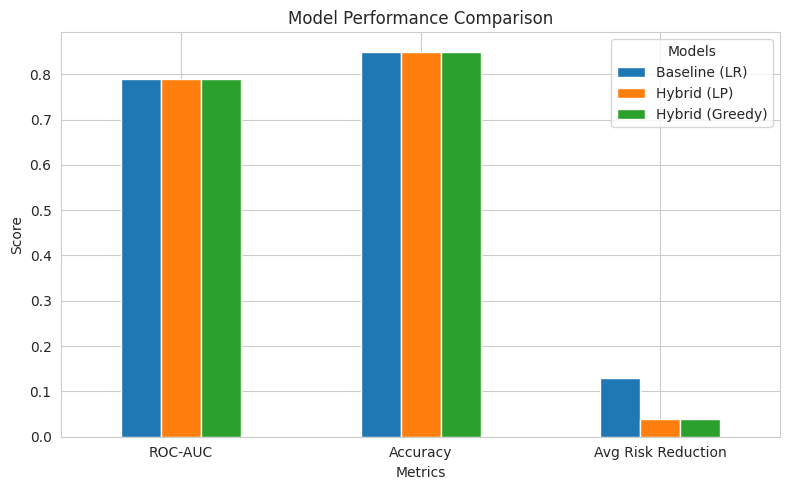

In [82]:
# Exclude ROI for better visual comparison
metrics_only = benchmark[
    benchmark["Metric"] != "ROI"
].set_index("Metric")

# Plot
ax = metrics_only.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.xticks(rotation=0)

plt.legend(title="Models")

plt.tight_layout()
plt.show()

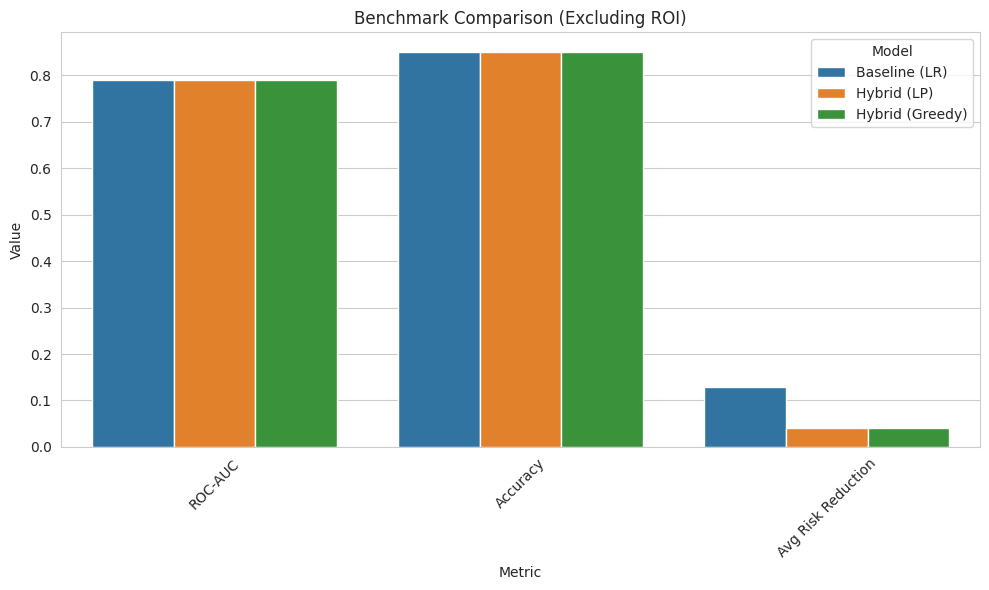

In [83]:
# Separate ROI
benchmark_no_roi = benchmark[benchmark["Metric"] != "ROI"]

plt.figure(figsize=(10,6))

benchmark_melt = benchmark_no_roi.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Value"
)

sns.barplot(data=benchmark_melt, x="Metric", y="Value", hue="Model")

plt.title("Benchmark Comparison (Excluding ROI)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

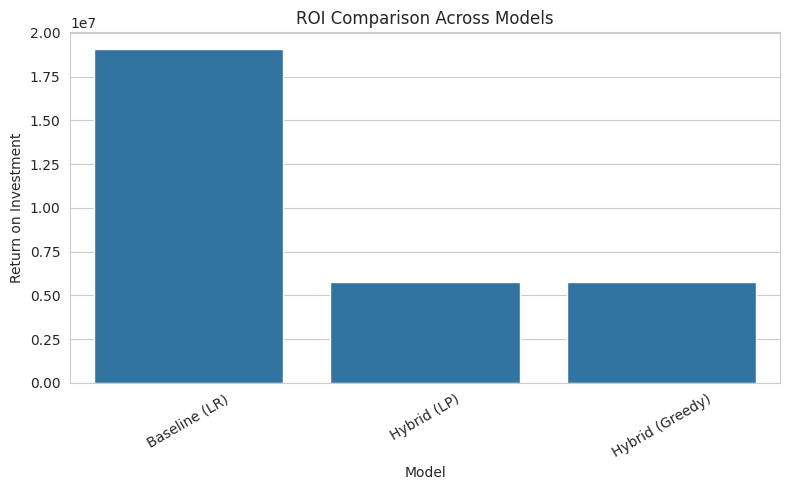

In [84]:
benchmark_roi = benchmark[benchmark["Metric"] == "ROI"]

plt.figure(figsize=(8,5))

benchmark_roi_melt = benchmark_roi.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Value"
)

sns.barplot(data=benchmark_roi_melt, x="Model", y="Value")

plt.title("ROI Comparison Across Models")
plt.ylabel("Return on Investment")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


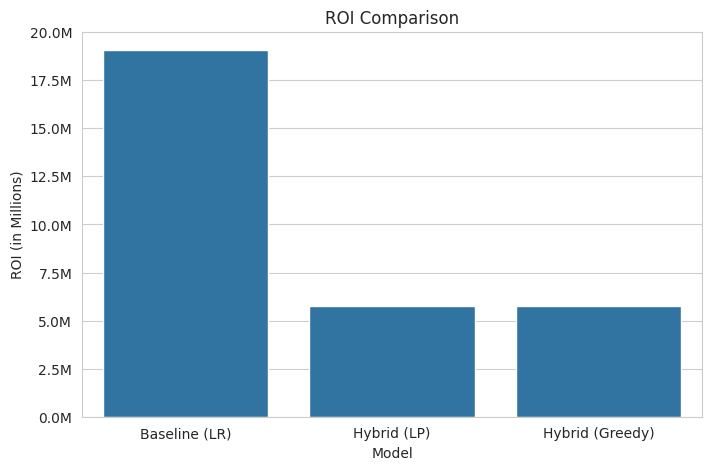

In [85]:
plt.figure(figsize=(8,5))

sns.barplot(data=benchmark_roi_melt, x="Model", y="Value")

plt.ylabel("ROI (in Millions)")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
)

plt.title("ROI Comparison")
plt.show()


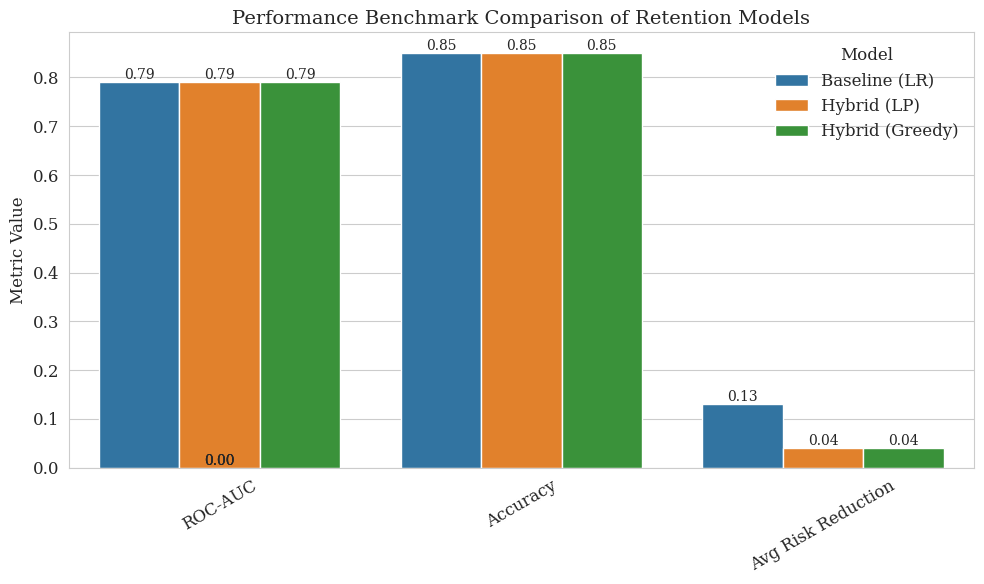

In [86]:
# Professional styling
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12
})

# Remove ROI
benchmark_no_roi = benchmark[benchmark["Metric"] != "ROI"]

benchmark_melt = benchmark_no_roi.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Value"
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=benchmark_melt,
    x="Metric",
    y="Value",
    hue="Model"
)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10)

plt.title("Performance Benchmark Comparison of Retention Models", fontsize=14)
plt.xlabel("")
plt.ylabel("Metric Value")
plt.xticks(rotation=30)

plt.legend(title="Model", frameon=False)
plt.tight_layout()

# Save high-resolution figure
plt.savefig("benchmark_metrics_publication.png", dpi=300)

plt.show()

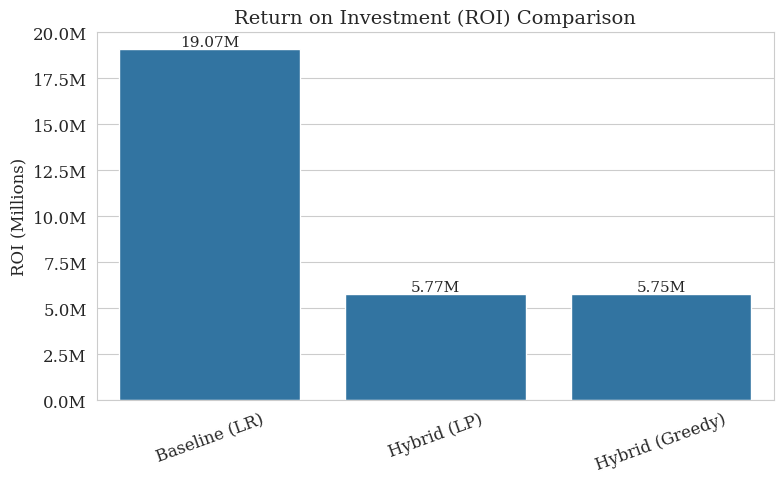

In [87]:
benchmark_roi = benchmark[benchmark["Metric"] == "ROI"]

benchmark_roi_melt = benchmark_roi.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Value"
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=benchmark_roi_melt,
    x="Model",
    y="Value"
)

# Convert to Millions
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
)

# Add value labels
for p in ax.patches:
    value = p.get_height() / 1e6
    ax.annotate(f'{value:.2f}M',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11)

plt.title("Return on Investment (ROI) Comparison", fontsize=14)
plt.xlabel("")
plt.ylabel("ROI (Millions)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("roi_publication.png", dpi=300)

plt.show()


In [88]:
budgets = np.linspace(100000, 1000000, 10)

roi_results = []

for b in budgets:
    remaining_budget = b
    temp_df = greedy_df.sort_values(by="EfficiencyScore", ascending=False).copy()
    selected = []

    for i in range(len(temp_df)):
        cost = temp_df.iloc[i]["ActionCost"]
        if cost <= remaining_budget:
            selected.append(1)
            remaining_budget -= cost
        else:
            selected.append(0)

    temp_df["Selected"] = selected
    temp_df["PostRisk"] = temp_df["FuzzyRisk"]

    for i in range(len(temp_df)):
        if temp_df.iloc[i]["Selected"] == 1:
            reduction = temp_df.iloc[i]["RiskReduction"]
            temp_df.iloc[i, temp_df.columns.get_loc("PostRisk")] *= (1 - reduction)

    reduction = temp_df["FuzzyRisk"].mean() - temp_df["PostRisk"].mean()
    roi = reduction * len(temp_df) * 100000
    roi_results.append(roi)


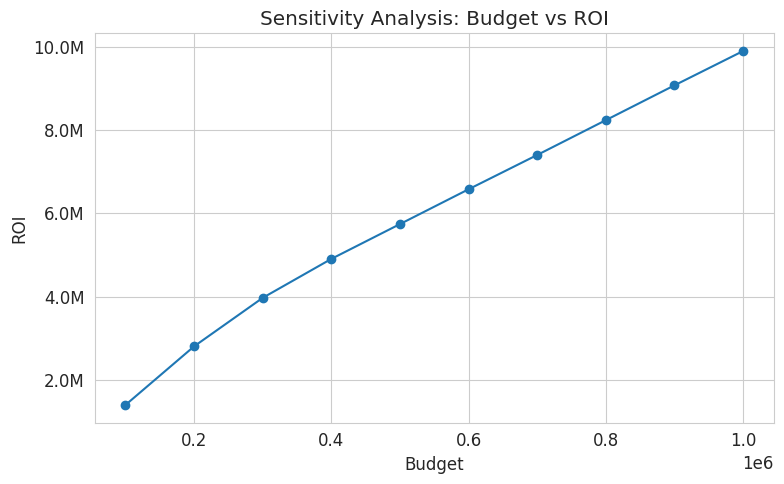

In [89]:
# Plot
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
plt.plot(budgets, roi_results, marker='o')

plt.title("Sensitivity Analysis: Budget vs ROI")
plt.xlabel("Budget")
plt.ylabel("ROI")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
)

plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=300)
plt.show()


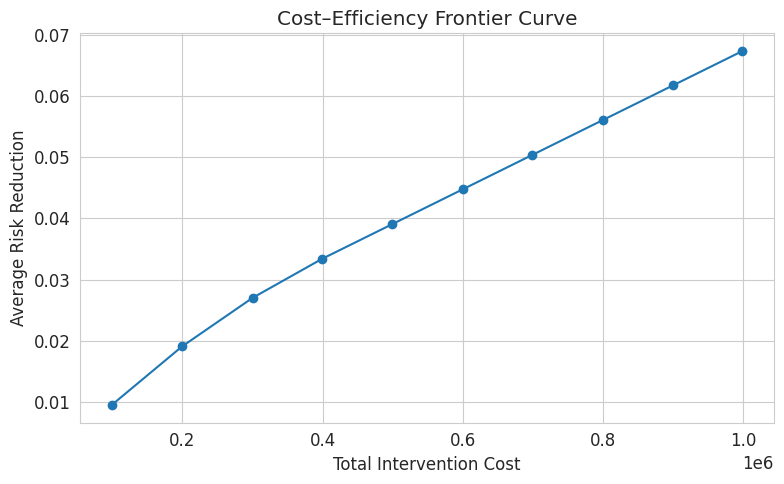

In [90]:
costs = []
reductions = []

for b in budgets:
    remaining_budget = b
    temp_df = greedy_df.sort_values(by="EfficiencyScore", ascending=False).copy()
    selected = []
    spent = 0

    for i in range(len(temp_df)):
        cost = temp_df.iloc[i]["ActionCost"]
        if cost <= remaining_budget:
            selected.append(1)
            remaining_budget -= cost
            spent += cost
        else:
            selected.append(0)

    temp_df["Selected"] = selected
    temp_df["PostRisk"] = temp_df["FuzzyRisk"]

    for i in range(len(temp_df)):
        if temp_df.iloc[i]["Selected"] == 1:
            reduction = temp_df.iloc[i]["RiskReduction"]
            temp_df.iloc[i, temp_df.columns.get_loc("PostRisk")] *= (1 - reduction)

    reduction = temp_df["FuzzyRisk"].mean() - temp_df["PostRisk"].mean()

    costs.append(spent)
    reductions.append(reduction)

plt.figure(figsize=(8,5))
plt.plot(costs, reductions, marker='o')

plt.title("Cost–Efficiency Frontier Curve")
plt.xlabel("Total Intervention Cost")
plt.ylabel("Average Risk Reduction")
plt.tight_layout()
plt.savefig("cost_efficiency_frontier.png", dpi=300)
plt.show()


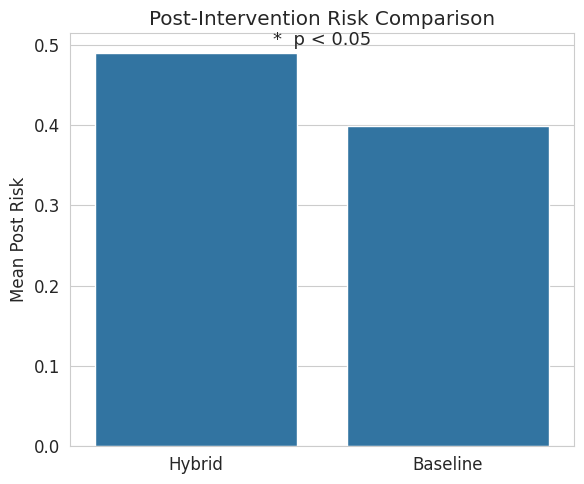

T-statistic: 28.302
P-value: 0.0


In [91]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    decision_df['Hybrid_PostRisk'],
    data['Baseline_PostRisk']
)

plt.figure(figsize=(6,5))

means = [
    decision_df['Hybrid_PostRisk'].mean(),
    data['Baseline_PostRisk'].mean()
]

sns.barplot(x=["Hybrid", "Baseline"], y=means)

# Significance annotation
if p_value < 0.05:
    plt.text(0.5, max(means)*1.02, "*  p < 0.05",
             ha='center', fontsize=13)

plt.title("Post-Intervention Risk Comparison")
plt.ylabel("Mean Post Risk")
plt.tight_layout()
plt.savefig("statistical_significance.png", dpi=300)
plt.show()

print("T-statistic:", round(t_stat,3))
print("P-value:", round(p_value,5))
